# Exploratory Data Analysis (EDA)

This notebook will:
1. Builds a smaller sample from the working dataset, since the full working dataset is too big to comfortably load.
2. Look at the shape, column types, and missing values.
3. Look at summary statistics (averages, min, max).
4. Explore how trips change over time.
5. Explore the distributions of trip distance, trip time, and fare.
6. Look at the relationship between trip distance and fare.
7. Look at the busiest pickup zones and how common shared rides are.

## Import the tools

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

## Chart Setup

We are doing four things here:
- Using the Cambria font.
- Removing the top and right border lines around each chart.
- Small tick marks on the axes inward instead of outward.
- Colour formatting

In [2]:
# Font
plt.rcParams["font.family"] = "Cambria"

# Borders: only keep the left and bottom lines around each chart
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# Tick marks
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"

# Colours
MAIN_COLOUR = "dodgerblue"    
SECOND_COLOUR = "darkorange"

## Folder Settings

In [3]:
# Folder to save the working dataset files
WORKING_DATA_FOLDER = "C:/Users/thiga/OneDrive/Documents/Masters - Big Data/Year 1/Semester 2/MIT 805/nyc_tlc_working"

# Folder where the raw files are kept
RAW_DATA_FOLDER = "C:/Users/thiga/nyc_tlc_raw"

# Folder to save the charts
FIGURES_FOLDER = "C:/Users/thiga/OneDrive/Documents/Masters - Big Data/Year 1/Semester 2/MIT 805/nyc_tlc_figures"

# Keep 5% of the rows in each moonth
SAMPLE_FRACTION = 0.05

RANDOM_SEED = 30

## Sample from every month

In [4]:
def find_working_files(folder_path):
    file_names = os.listdir(folder_path)

    parquet_file_names = []
    for name in file_names:
        if name.endswith(".parquet"):
            parquet_file_names.append(name)

    return parquet_file_names


working_file_names = find_working_files(WORKING_DATA_FOLDER)
print("Found " + str(len(working_file_names)) + " working files.")

list_of_samples = []

files_done = 0
for file_name in working_file_names:
    files_done = files_done + 1

    file_path = os.path.join(WORKING_DATA_FOLDER, file_name)
    one_month_data = pd.read_parquet(file_path)

    sample_from_this_month = one_month_data.sample(frac=SAMPLE_FRACTION, random_state=RANDOM_SEED)

    list_of_samples.append(sample_from_this_month)

    print("File " + str(files_done) + " of " + str(len(working_file_names))+ " (" + file_name + "): sampled " + str(len(sample_from_this_month))
          + " rows out of " + str(len(one_month_data)))

# Combine all the samples from individual months into one table
sample_data = pd.concat(list_of_samples)

print("Total rows in our combined sample: " + str(len(sample_data)))

Found 73 working files.
File 1 of 73 (fhvhv_tripdata_2019-02.parquet): sampled 1003775 rows out of 20075504
File 2 of 73 (fhvhv_tripdata_2019-03.parquet): sampled 1189132 rows out of 23782640
File 3 of 73 (fhvhv_tripdata_2019-04.parquet): sampled 1082572 rows out of 21651444
File 4 of 73 (fhvhv_tripdata_2019-05.parquet): sampled 1113282 rows out of 22265634
File 5 of 73 (fhvhv_tripdata_2019-06.parquet): sampled 1047577 rows out of 20951546
File 6 of 73 (fhvhv_tripdata_2019-07.parquet): sampled 1011127 rows out of 20222546
File 7 of 73 (fhvhv_tripdata_2019-08.parquet): sampled 1004228 rows out of 20084568
File 8 of 73 (fhvhv_tripdata_2019-09.parquet): sampled 1000095 rows out of 20001902
File 9 of 73 (fhvhv_tripdata_2019-10.parquet): sampled 1055157 rows out of 21103148
File 10 of 73 (fhvhv_tripdata_2019-11.parquet): sampled 1078906 rows out of 21578124
File 11 of 73 (fhvhv_tripdata_2019-12.parquet): sampled 1090278 rows out of 21805569
File 12 of 73 (fhvhv_tripdata_2020-01.parquet): sa

## Check shape and column types


In [5]:
print("Number of rows: " + str(sample_data.shape[0]))
print("Number of columns: " + str(sample_data.shape[1]))
print("Column names and data types:")
print(sample_data.dtypes)

Number of rows: 64159022
Number of columns: 11
Column names and data types:
hvfhs_license_num              object
pickup_datetime        datetime64[us]
dropoff_datetime       datetime64[us]
PULocationID                    int64
DOLocationID                    int64
trip_miles                    float64
trip_time                       int64
base_passenger_fare           float64
tips                          float64
driver_pay                    float64
shared_request_flag            object
dtype: object


## Check for missing values

In [6]:
print("Number of missing values in each column:")
print(sample_data.isnull().sum())

Number of missing values in each column:
hvfhs_license_num      0
pickup_datetime        0
dropoff_datetime       0
PULocationID           0
DOLocationID           0
trip_miles             0
trip_time              0
base_passenger_fare    0
tips                   0
driver_pay             0
shared_request_flag    0
dtype: int64


## Summary statistics

In [7]:
sample_data.describe()

,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,trip_miles,trip_time,base_passenger_fare,tips,driver_pay
count,64159022,64159022,6.415902e+07,6.415902e+07,6.415902e+07,6.415902e+07,6.415902e+07,6.415902e+07,6.415902e+07
mean,2022-05-16 04:58:16.457410,2022-05-16 05:17:26.568672,1.382226e+02,1.416454e+02,4.913064e+00,1.149729e+03,2.243956e+01,9.294270e-01,1.780643e+01
min,2019-02-01 00:00:01,2019-02-01 00:02:44,1.000000e+00,1.000000e+00,1.000000e-03,1.000000e+00,0.000000e+00,0.000000e+00,-1.345000e+02
25%,2020-08-12 07:55:54.750000,2020-08-12 08:13:42.500000,7.400000e+01,7.500000e+01,1.580000e+00,5.860000e+02,1.035000e+01,0.000000e+00,7.910000e+00
50%,2022-09-11 01:48:17,2022-09-11 02:06:00,1.390000e+02,1.410000e+02,2.960000e+00,9.350000e+02,1.671000e+01,0.000000e+00,1.327000e+01
75%,2024-02-01 06:50:40.250000,2024-02-01 07:07:39.750000,2.100000e+02,2.160000e+02,6.070000e+00,1.471000e+03,2.739000e+01,0.000000e+00,2.237000e+01
max,2025-05-31 23:59:56,2025-06-01 01:00:42,2.650000e+02,2.650000e+02,6.124400e+02,7.160600e+04,8.157740e+03,5.000000e+02,4.894620e+03
std,NaN,NaN,7.518190e+01,7.791929e+01,5.686413e+00,8.234754e+02,2.013093e+01,2.933004e+00,1.580373e+01


## Add clear date and time columns

In [8]:
sample_data["pickup_year"] = sample_data["pickup_datetime"].dt.year
sample_data["pickup_month"] = sample_data["pickup_datetime"].dt.month
sample_data["pickup_hour"] = sample_data["pickup_datetime"].dt.hour
sample_data["pickup_day_name"] = sample_data["pickup_datetime"].dt.day_name()

# "year-month" label 
sample_data["year_month"] = (sample_data["pickup_year"].astype(str) + "-"+ sample_data["pickup_month"].astype(str).str.zfill(2))

# Convert trip time to minutes
sample_data["trip_time_minutes"] = sample_data["trip_time"] / 60

sample_data[["pickup_datetime", "pickup_year", "pickup_month", "pickup_hour", "pickup_day_name", "year_month", "trip_time_minutes"]].head()

,pickup_datetime,pickup_year,pickup_month,pickup_hour,pickup_day_name,year_month,trip_time_minutes
3783268,2019-02-06 08:11:43,2019,2,8,Wednesday,2019-02,33.750000
13176491,2019-02-19 10:02:47,2019,2,10,Tuesday,2019-02,3.133333
17380040,2019-02-25 01:55:20,2019,2,1,Monday,2019-02,24.166667
4042466,2019-02-06 17:25:21,2019,2,17,Wednesday,2019-02,13.933333
17715754,2019-02-25 15:10:04,2019,2,15,Monday,2019-02,12.766667


## How many trips happened over time?

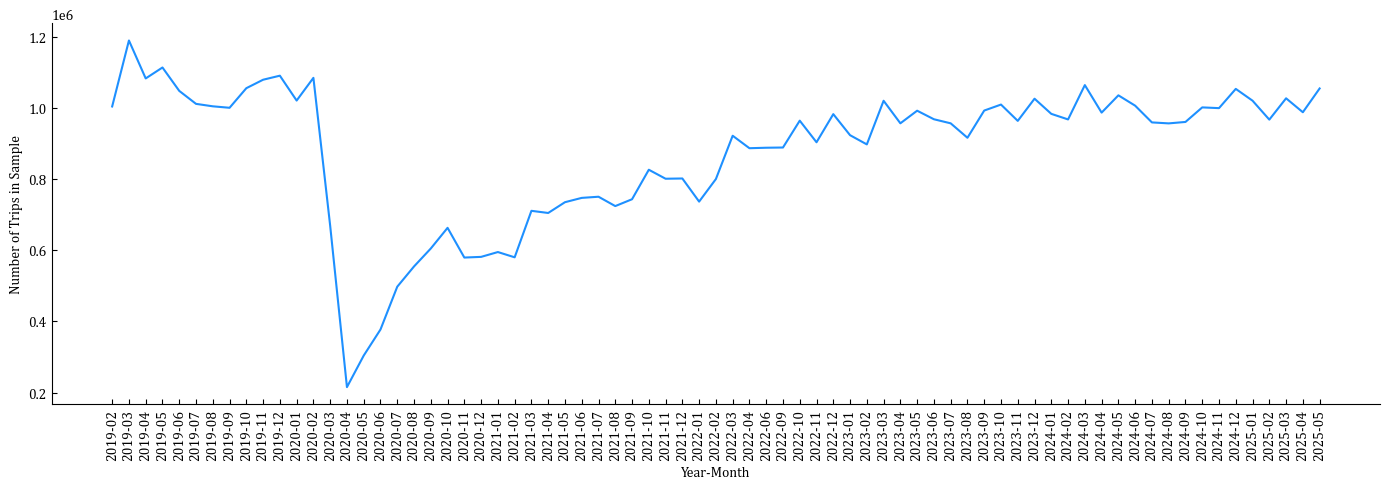

In [9]:
trips_per_month = sample_data.groupby("year_month").size()

# Put months in time order
trips_per_month = trips_per_month.sort_index()

plt.figure(figsize=(14, 5))
plt.plot(trips_per_month.index, trips_per_month.values, color=MAIN_COLOUR)
# plt.title("Number of Sampled Trips per Month (2019-2025)")
plt.xlabel("Year-Month")
plt.ylabel("Number of Trips in Sample")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_FOLDER, "trips_per_month.png"), dpi=300, bbox_inches="tight")
plt.show()

## What time of day are trips most common?

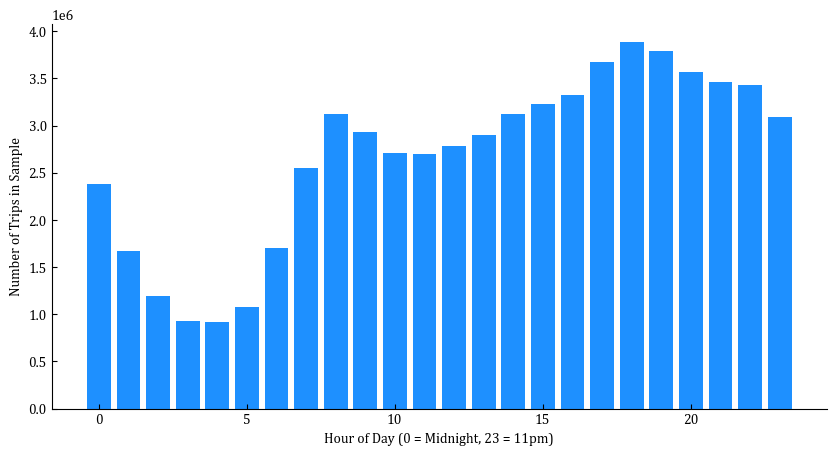

In [10]:
trips_per_hour = sample_data.groupby("pickup_hour").size()

plt.figure(figsize=(10, 5))
plt.bar(trips_per_hour.index, trips_per_hour.values, color=MAIN_COLOUR)
# plt.title("Number of Sampled Trips by Hour of Day")
plt.xlabel("Hour of Day (0 = Midnight, 23 = 11pm)")
plt.ylabel("Number of Trips in Sample")
plt.savefig(os.path.join(FIGURES_FOLDER, "trips_by_hour.png"), dpi=300, bbox_inches="tight")
plt.show()

## What days of the week are busiest?

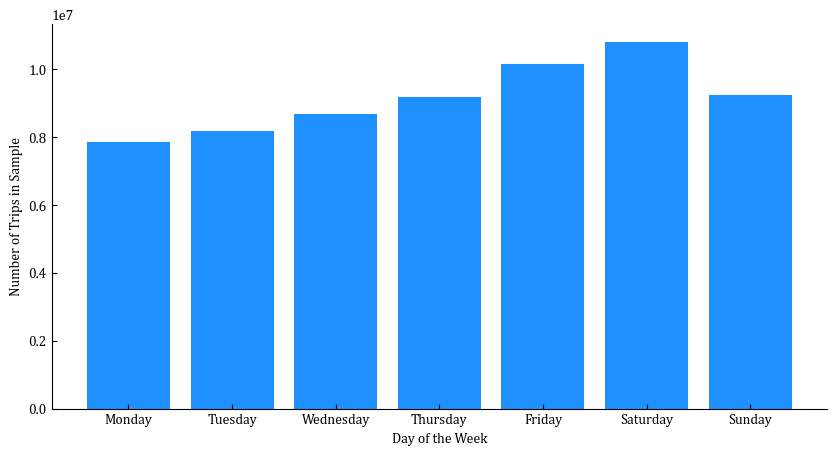

In [11]:
trips_per_day = sample_data.groupby("pickup_day_name").size()

# Sort days Monday to Sunday
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
trips_per_day = trips_per_day.reindex(day_order)

plt.figure(figsize=(10, 5))
plt.bar(trips_per_day.index, trips_per_day.values, color=MAIN_COLOUR)
# plt.title("Number of Sampled Trips by Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Number of Trips in Sample")
plt.savefig(os.path.join(FIGURES_FOLDER, "trips_by_day_of_week.png"), dpi=300, bbox_inches="tight")
plt.show()

## Distributions of trip distance, trip time, and fare

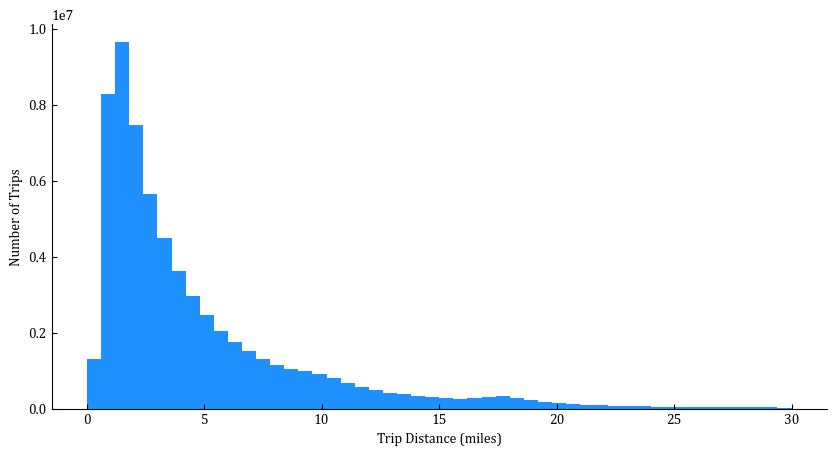

In [12]:
plt.figure(figsize=(10, 5))
plt.hist(sample_data["trip_miles"], bins=50, range=(0, 30), color=MAIN_COLOUR)
# plt.title("Distribution of Trip Distance")
plt.xlabel("Trip Distance (miles)")
plt.ylabel("Number of Trips")
plt.savefig(os.path.join(FIGURES_FOLDER, "distribution_trip_distance.png"), dpi=300, bbox_inches="tight")
plt.show()

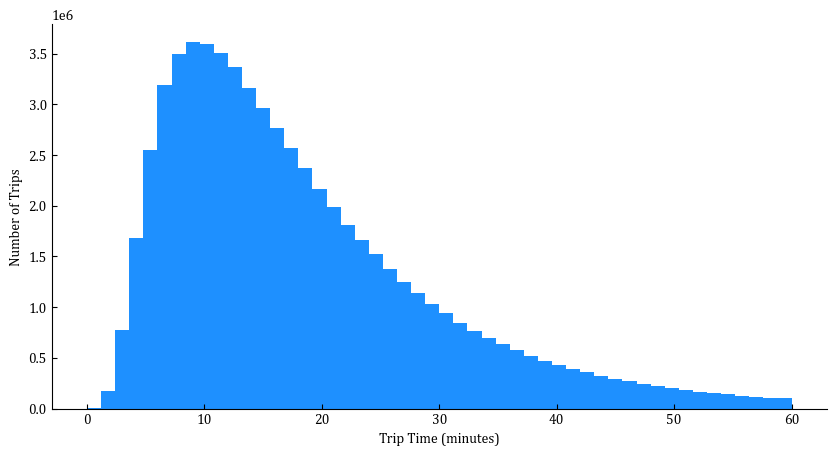

In [13]:
plt.figure(figsize=(10, 5))
plt.hist(sample_data["trip_time_minutes"], bins=50, range=(0, 60), color=MAIN_COLOUR)
# plt.title("Distribution of Trip Time")
plt.xlabel("Trip Time (minutes)")
plt.ylabel("Number of Trips")
plt.savefig(os.path.join(FIGURES_FOLDER, "distribution_trip_time.png"), dpi=300, bbox_inches="tight")
plt.show()

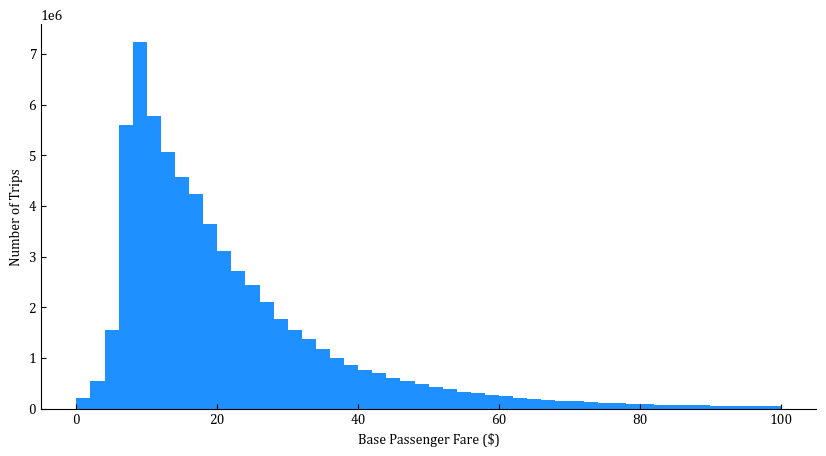

In [14]:
plt.figure(figsize=(10, 5))
plt.hist(sample_data["base_passenger_fare"], bins=50, range=(0, 100), color=MAIN_COLOUR)
# plt.title("Distribution of Base Passenger Fare")
plt.xlabel("Base Passenger Fare ($)")
plt.ylabel("Number of Trips")
plt.savefig(os.path.join(FIGURES_FOLDER, "distribution_base_fare.png"), dpi=300, bbox_inches="tight")
plt.show()

## Outliers

The charts above only display values in a normal range. However, extreme values are still sitting in the data.

In [15]:
trips_over_30_miles = sample_data[sample_data["trip_miles"] > 30]
trips_over_60_minutes = sample_data[sample_data["trip_time_minutes"] > 60]
trips_over_100_fare = sample_data[sample_data["base_passenger_fare"] > 100]

print("Trips longer than 30 miles: " + str(len(trips_over_30_miles)) + " out of " + str(len(sample_data)))
print("Trips longer than 60 minutes: " + str(len(trips_over_60_minutes)) + " out of " + str(len(sample_data)))
print("Trips with fare over $100: " + str(len(trips_over_100_fare)) + " out of " + str(len(sample_data)))
print("")
print("Largest trip_miles value in our sample: " + str(sample_data["trip_miles"].max()))
print("Largest trip_time_minutes value in our sample: " + str(sample_data["trip_time_minutes"].max()))
print("Largest base_passenger_fare value in our sample: " + str(sample_data["base_passenger_fare"].max()))

Trips longer than 30 miles: 404732 out of 64159022
Trips longer than 60 minutes: 1110460 out of 64159022
Trips with fare over $100: 653602 out of 64159022

Largest trip_miles value in our sample: 612.44
Largest trip_time_minutes value in our sample: 1193.4333333333334
Largest base_passenger_fare value in our sample: 8157.74


## Relationship between trip distance and fare

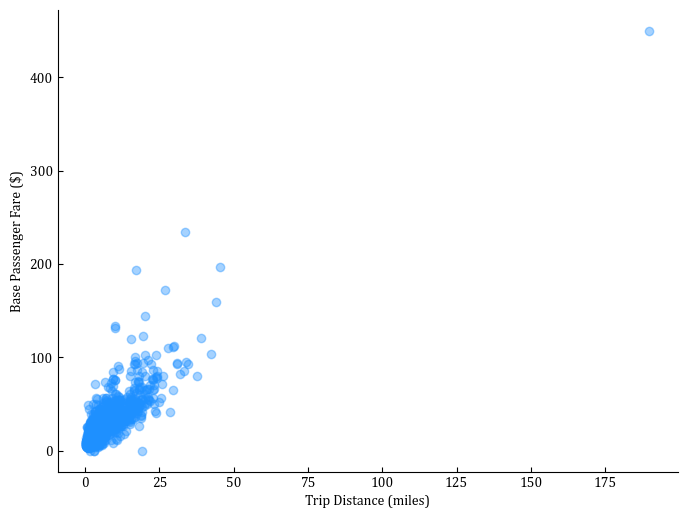

Correlation between trip distance and fare: 0.851


In [16]:
plot_sample_size = min(2000, len(sample_data))
plot_sample = sample_data.sample(n=plot_sample_size, random_state=RANDOM_SEED)

plt.figure(figsize=(8, 6))
plt.scatter(plot_sample["trip_miles"], plot_sample["base_passenger_fare"], alpha=0.4, color=MAIN_COLOUR)
# plt.title("Trip Distance vs Fare (sample of " + str(plot_sample_size) + " trips)")
plt.xlabel("Trip Distance (miles)")
plt.ylabel("Base Passenger Fare ($)")
plt.savefig(os.path.join(FIGURES_FOLDER, "distance_vs_fare_scatter.png"), dpi=300, bbox_inches="tight")
plt.show()

correlation_value = sample_data["trip_miles"].corr(sample_data["base_passenger_fare"])
print("Correlation between trip distance and fare: " + str(round(correlation_value, 3)))

## Busiest pickup zones

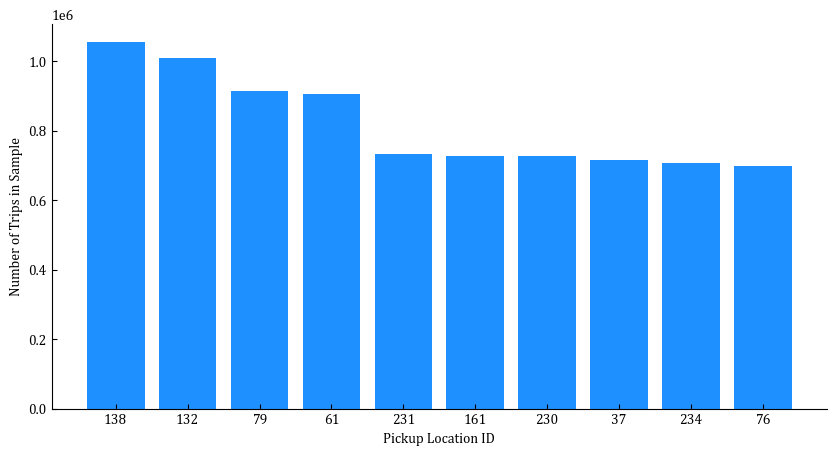

In [17]:
top_pickup_zones = sample_data["PULocationID"].value_counts().head(10)

plt.figure(figsize=(10, 5))
plt.bar(top_pickup_zones.index.astype(str), top_pickup_zones.values, color=MAIN_COLOUR)
# plt.title("Top 10 Busiest Pickup Zones (by Location ID)")
plt.xlabel("Pickup Location ID")
plt.ylabel("Number of Trips in Sample")
plt.savefig(os.path.join(FIGURES_FOLDER, "top_pickup_zones.png"), dpi=300, bbox_inches="tight")
plt.show()

## Are rides often shared?


Shared ride counts: shared_request_flag
N    60174881
Y     3984141
Name: count, dtype: int64


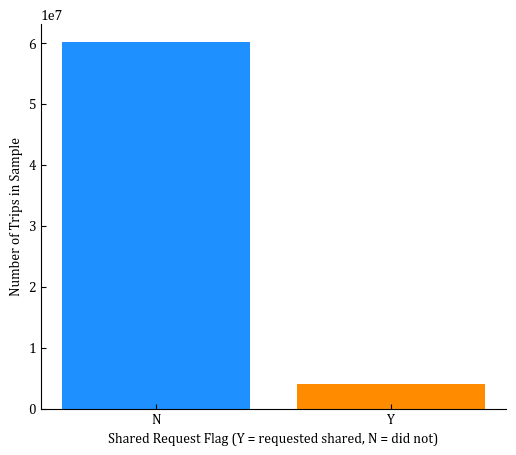

In [18]:
shared_ride_counts = sample_data["shared_request_flag"].value_counts()
print("Shared ride counts:", shared_ride_counts)

CATEGORY_COLOURS = {"Y": SECOND_COLOUR, "N": MAIN_COLOUR}
bar_colours = []
for category_label in shared_ride_counts.index:
    bar_colours.append(CATEGORY_COLOURS[str(category_label)])

plt.figure(figsize=(6, 5))
plt.bar(shared_ride_counts.index.astype(str), shared_ride_counts.values, color=bar_colours)
# plt.title("Requested Shared Rides vs Solo Rides")
plt.xlabel("Shared Request Flag (Y = requested shared, N = did not)")
plt.ylabel("Number of Trips in Sample")
plt.savefig(os.path.join(FIGURES_FOLDER, "shared_rides_vs_solo.png"), dpi=300, bbox_inches="tight")
plt.show()

## Exact monthly trip counts

Everything above uses the 5% sample. For a clear before/after COVID comparison we need all the numbers.

In [19]:
monthly_trip_counts = {}

for file_name in working_file_names:
    file_path = os.path.join(WORKING_DATA_FOLDER, file_name)
    one_month_data = pd.read_parquet(file_path)

    year_month = file_name.replace("fhvhv_tripdata_", "").replace(".parquet", "")
    monthly_trip_counts[year_month] = len(one_month_data)

for year_month in sorted(monthly_trip_counts.keys()):
    print(year_month + ": " + str(monthly_trip_counts[year_month]) + " trips")

2019-02: 20075504 trips
2019-03: 23782640 trips
2019-04: 21651444 trips
2019-05: 22265634 trips
2019-06: 20951546 trips
2019-07: 20222546 trips
2019-08: 20084568 trips
2019-09: 20001902 trips
2019-10: 21103148 trips
2019-11: 21578124 trips
2019-12: 21805569 trips
2020-01: 20408265 trips
2020-02: 21684226 trips
2020-03: 13370183 trips
2020-04: 4306250 trips
2020-05: 6079705 trips
2020-06: 7544359 trips
2020-07: 9949063 trips
2020-08: 11087463 trips
2020-09: 12095966 trips
2020-10: 13256489 trips
2020-11: 11586838 trips
2020-12: 11624880 trips
2021-01: 11895978 trips
2021-02: 11600145 trips
2021-03: 14212246 trips
2021-04: 14091412 trips
2021-05: 14696803 trips
2021-06: 14939351 trips
2021-07: 15004340 trips
2021-08: 14478481 trips
2021-09: 14863192 trips
2021-10: 16520984 trips
2021-11: 16015451 trips
2021-12: 16029480 trips
2022-01: 14730282 trips
2022-02: 15998375 trips
2022-03: 18431344 trips
2022-04: 17730497 trips
2022-06: 17757099 trips
2022-09: 17769603 trips
2022-10: 19278299 tr

## Driver pay share before and after December 2023

NYC changed its driver minimum pay rule around December 2023.

In [20]:
# Driver's share of the fare = the percentage of the base fare that goes to the driver.
# Since driver_pay is already part of base_passenger_fare: calculate: driver_pay / base_passenger_fare

sample_data["driver_share"] = sample_data["driver_pay"] / sample_data["base_passenger_fare"]
sample_data.loc[sample_data["base_passenger_fare"] <= 0, "driver_share"] = None

cutoff_date = pd.to_datetime("2023-12-01")
before_date = sample_data[sample_data["pickup_datetime"] < cutoff_date]
after_date = sample_data[sample_data["pickup_datetime"] >= cutoff_date]

print("Average driver pay per trip before Dec 2023: $" + str(round(before_date["driver_pay"].mean(), 2)))
print("Average driver pay per trip after Dec 2023: $" + str(round(after_date["driver_pay"].mean(), 2)))
print("")
print("Average driver share before Dec 2023: " + str(round(before_date["driver_share"].mean() * 100, 1)) + "%")
print("Average driver share after Dec 2023: " + str(round(after_date["driver_share"].mean() * 100, 1)) + "%")

Average driver pay per trip before Dec 2023: $16.88
Average driver pay per trip after Dec 2023: $20.17

Average driver share before Dec 2023: 84.6%
Average driver share after Dec 2023: 77.7%


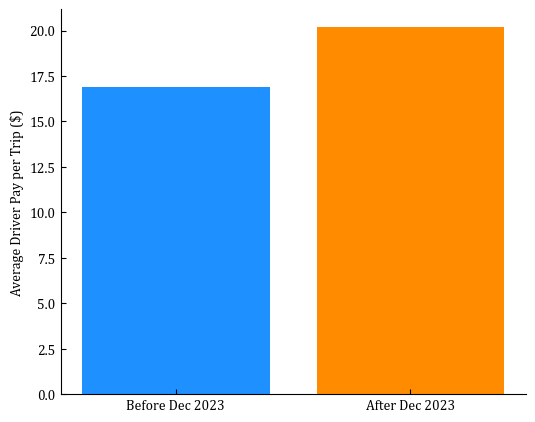

In [21]:
average_pay_before = before_date["driver_pay"].mean()
average_pay_after = after_date["driver_pay"].mean()

average_share_before = before_date["driver_share"].mean() * 100
average_share_after = after_date["driver_share"].mean() * 100

# Chart 1: average driver pay per trip, before vs after
plt.figure(figsize=(6, 5))
plt.bar(["Before Dec 2023", "After Dec 2023"], [average_pay_before, average_pay_after], color=[MAIN_COLOUR, SECOND_COLOUR])
# plt.title("Average Driver Pay per Trip: Before vs After Dec 2023")
plt.ylabel("Average Driver Pay per Trip ($)")
plt.savefig(os.path.join(FIGURES_FOLDER, "driver_pay_before_after.png"), dpi=300, bbox_inches="tight")
plt.show()

## Congestion pricing impact (January - May 2025)

NYC's congestion pricing started in January 2025.

In [22]:
import pyarrow.parquet as pq

congestion_months = [
    "fhvhv_tripdata_2025-01.parquet",
    "fhvhv_tripdata_2025-02.parquet",
    "fhvhv_tripdata_2025-03.parquet",
    "fhvhv_tripdata_2025-04.parquet",
    "fhvhv_tripdata_2025-05.parquet",]

percent_with_fee_by_month = {}
average_fare_by_month = {}

for file_name in congestion_months:
    file_path = os.path.join(RAW_DATA_FOLDER, file_name)
    file_schema = pq.ParquetFile(file_path).schema_arrow

    if "cbd_congestion_fee" in file_schema.names:
        month_data = pd.read_parquet(file_path, columns=["cbd_congestion_fee", "base_passenger_fare"])

        total_trips = len(month_data)
        trips_with_fee = month_data[month_data["cbd_congestion_fee"] > 0]
        number_with_fee = len(trips_with_fee)
        percent_with_fee = (number_with_fee / total_trips) * 100
        average_fare = month_data["base_passenger_fare"].mean()

        year_month = file_name.replace("fhvhv_tripdata_", "").replace(".parquet", "")
        percent_with_fee_by_month[year_month] = percent_with_fee
        average_fare_by_month[year_month] = average_fare

        print(file_name)
        print("Total trips: " + str(total_trips))
        print("Trips with congestion fee: " + str(number_with_fee) + " (" + str(round(percent_with_fee, 1)) + "%)")
        print("Average base fare: $" + str(round(average_fare, 2)))
        print("")
    else:
        print(file_name + " no cbd_congestion_fee column found")

fhvhv_tripdata_2025-01.parquet
Total trips: 20405666
Trips with congestion fee: 6300212 (30.9%)
Average base fare: $24.27

fhvhv_tripdata_2025-02.parquet
Total trips: 19339461
Trips with congestion fee: 6825496 (35.3%)
Average base fare: $24.97

fhvhv_tripdata_2025-03.parquet
Total trips: 20536879
Trips with congestion fee: 7030970 (34.2%)
Average base fare: $27.61

fhvhv_tripdata_2025-04.parquet
Total trips: 19753983
Trips with congestion fee: 6927499 (35.1%)
Average base fare: $26.47

fhvhv_tripdata_2025-05.parquet
Total trips: 21091193
Trips with congestion fee: 7239749 (34.3%)
Average base fare: $28.1



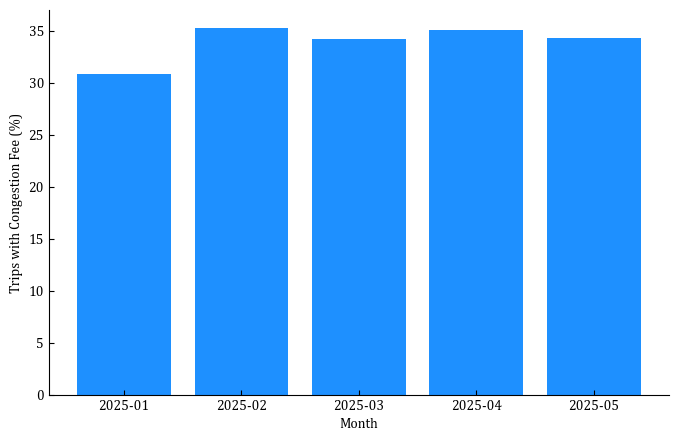

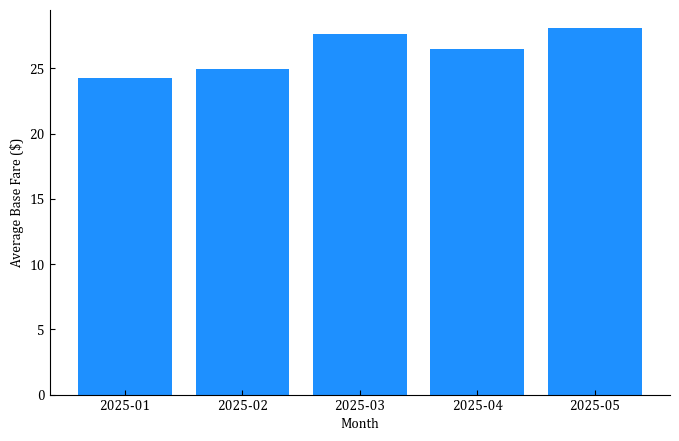

In [23]:
months_list = sorted(percent_with_fee_by_month.keys())

plt.figure(figsize=(8, 5))
plt.bar(months_list, [percent_with_fee_by_month[m] for m in months_list], color=MAIN_COLOUR)
# plt.title("Percentage of Trips Charged the Congestion Fee (Jan-May 2025)")
plt.xlabel("Month")
plt.ylabel("Trips with Congestion Fee (%)")
plt.savefig(os.path.join(FIGURES_FOLDER, "congestion_fee_percent_by_month.png"), dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(months_list, [average_fare_by_month[m] for m in months_list], color=MAIN_COLOUR)
# plt.title("Average Base Fare by Month (Jan-May 2025)")
plt.xlabel("Month")
plt.ylabel("Average Base Fare ($)")
plt.savefig(os.path.join(FIGURES_FOLDER, "average_fare_by_month.png"), dpi=300, bbox_inches="tight")
plt.show()